# Test 1: Isolated Controller and Signal
Use a modified IEEE 14-bus setup with a VSM grid-forming inverter (REGF2) replacing synchronous generator 3 (GENROU_3). 

In [2]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets

print(test_case_dir)

/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/test_cases


In [3]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=30)

import new file (pls pls work)

In [4]:
case_path = andes.get_case(test_case_dir / "1_isolated_controller.xlsx")
ss_ref = andes.load(case_path)

#andes.config_logger(stream_level=10)  # DEBUG level
ss_ref.PFlow.run()

gen_idxs = list(ss_ref.GENROU.idx.v)
gen_buses = list(ss_ref.GENROU.bus.v)
M_base = ss_ref.GENROU.M.v.copy()

# get only active generators
u = ss_ref.GENROU.u.v
u_active = active = u.astype(bool)

gen_info = pd.DataFrame({"gen_idx": gen_idxs, "bus": gen_buses, "M": M_base})
gen_info.sort_values("M", ascending=False)


,gen_idx,bus,M
1,GENROU_2,2,13.0
2,GENROU_3,3,10.0
3,GENROU_4,6,10.0
4,GENROU_5,8,10.0
0,GENROU_1,1,8.0


In [5]:
regf2_idxs = list(ss_ref.REGF2.idx.v)
regf2_buses = list(ss_ref.REGF2.bus.v)
#regf2_M_base = ss_ref.REGF2.M.v.copy()

gen_info = pd.DataFrame({"gen_idx": regf2_idxs, "bus": regf2_buses})
gen_info.sort_values("gen_idx", ascending=False)

,gen_idx,bus
0,REGF2_1,3


## Set Up Fault and Run TDS
Trip the synchronous generator with the highest inertia (GENROU 2) at t = 1s.  $\alpha$ (inertia scaling) set to lowest (0.15). 

In [76]:
trip_idx = gen_idxs[int(np.argmax(M_base))] # trip the generator with the largest inertia
print(trip_idx)

# inertia_scales = [1.0, 0.7, 0.5, 0.4, 0.3, 0.2, 0.15] just testing lowest
alpha = 0.15

ss = andes.load(case_path, setup=False)
ss.add("Toggle", model="GENROU", dev=trip_idx, t=1.0)
ss.setup()
ss.config.warn_abnormal = 0
ss.GENROU.M.v[:] = M_base * alpha

ss.PFlow.run()
ss.TDS.config.tf = 8
ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 0 # ignore stability criteria (run until end of simulation time)

ss.TDS.run()

results = ss.TDS.get_timeseries(ss.GENROU.omega)

GENROU_2


## Results

### COI Frequency

          GENROU_1  GENROU_2  GENROU_3  GENROU_4  GENROU_5
0.000000  1.000000       1.0       0.0  1.000000  1.000000
0.033333  1.000000       1.0       0.0  1.000000  1.000000
0.066667  1.000000       1.0       0.0  1.000000  1.000000
0.100000  1.000000       1.0       0.0  1.000000  1.000000
0.133333  1.000000       1.0       0.0  1.000000  1.000000
...            ...       ...       ...       ...       ...
7.866767  0.995319       1.0       0.0  0.995354  0.995355
7.900100  0.995320       1.0       0.0  0.995354  0.995355
7.933433  0.995320       1.0       0.0  0.995354  0.995355
7.966767  0.995320       1.0       0.0  0.995354  0.995355
8.000000  0.995321       1.0       0.0  0.995354  0.995355

[243 rows x 5 columns]


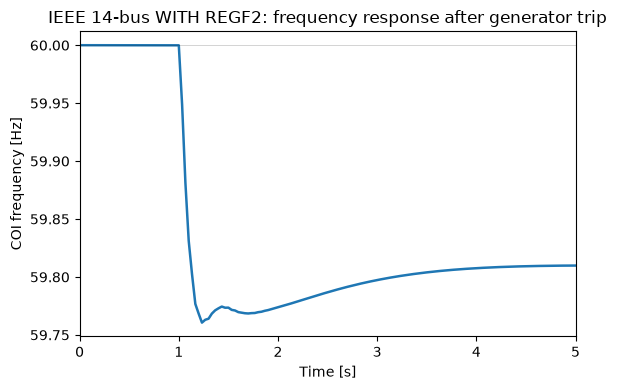

In [84]:
# plotting
weights = M_base[active] / M_base[active].sum()
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

print(results)

f_coi = (results.loc[:, active].values * weights).sum(axis=1) * 60
ax.plot(results.index, f_coi, color="tab:blue", linewidth=1.8,
        label=f"$\\alpha$ = {alpha}")

ax.set_xlabel("Time [s]")
ax.set_ylabel("COI frequency [Hz]")
ax.set_title("IEEE 14-bus WITH REGF2: frequency response after generator trip")
ax.set_xlim(0.0, 5.0)
ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)

plt.tight_layout()

### Nadir & RoCoF

In [ ]:
f_coi = (results.loc[:, active].values * weights).sum(axis=1) * 60
t = results.index.values

nadir = f_coi[t > 1.0].min()

post = (t >= 1.0) & (t <= 2.0)
t_post, f_post = t[post], f_coi[post]
rocof = np.max(np.abs(np.diff(f_post) / np.diff(t_post)))

print("Nadir: " + str(nadir))
print ("RoCoF: " + str(rocof))

Nadir: 59.76060301456036
RoCoF: 2.0246012701117104


### Voltages

In [75]:
voltage_df = ss.TDS.get_timeseries(ss.Bus.v)
print(f"Voltage DataFrame shape: {voltage_df.shape}")
print(f"Columns (bus indices): {list(voltage_df.columns)}")

Voltage DataFrame shape: (243, 14)
Columns (bus indices): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


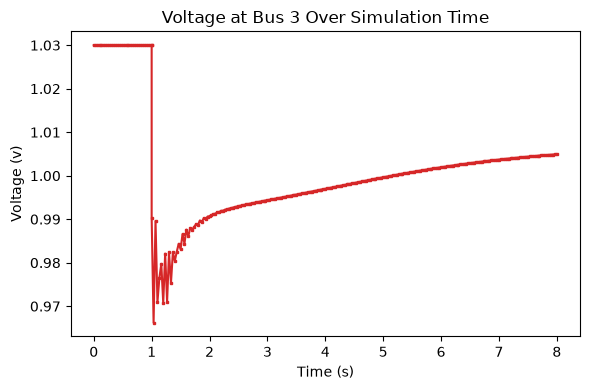

In [73]:
voltage_bus3 = voltage_df[2]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(voltage_bus3.index, voltage_bus3, "s-", color="tab:red",
        markersize=1.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (v)")
ax.set_title("Voltage at Bus 3 Over Simulation Time")

plt.tight_layout()

(0.0, 5.0)

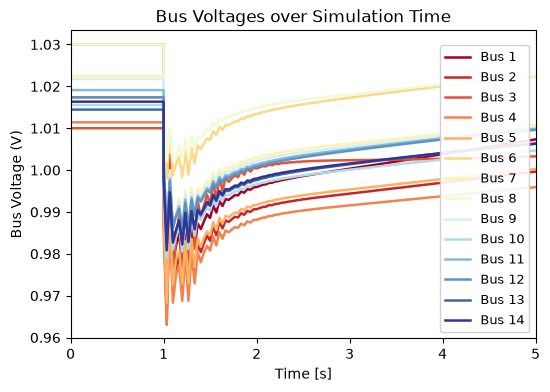

In [86]:
# Voltage at All Buses
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, bus in enumerate(voltage_df.columns):
    color = cmap(i / (len(voltage_df.columns) - 1))

    ax.plot(voltage_df.index, voltage_df[bus], color=color, linewidth=1.8,
            label=f"Bus {bus}")

ax.set_xlabel("Time [s]")
ax.set_ylabel("Bus Voltage (V)")
ax.set_title("Bus Voltages over Simulation Time")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(0.0, 5.0)
# ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)


### Power Delivered
Report delivered power (as measured by controller signal)

In [60]:
power_regf2_df = ss.TDS.get_timeseries(ss.REGF2.Pe)
power_regf2_df

,REGF2_1
0.000000,0.400000
0.033333,0.400000
0.066667,0.400000
0.100000,0.400000
0.133333,0.400000
...,...
7.866767,0.480239
7.900100,0.480240
7.933433,0.480240
7.966767,0.480240


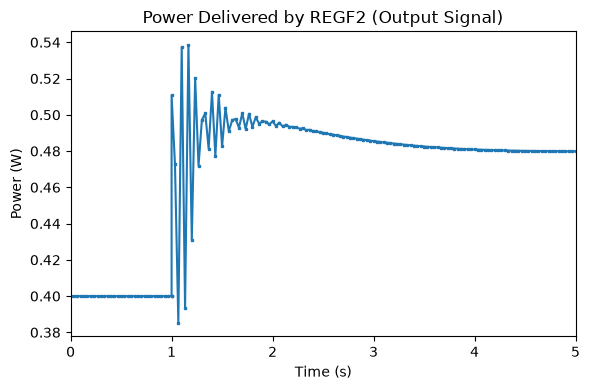

In [ ]:
# power delivered by REGF2 ONLY
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(power_regf2_df.index, power_regf2_df, "s-", color="tab:blue",
        markersize=1.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (W)")
ax.set_xlim(0.0, 5.0)

ax.set_title("Power Delivered by REGF2 (Output Signal)")

plt.tight_layout()

          GENROU_1      GENROU_2  GENROU_4  GENROU_5
0.000000  0.814272  4.000000e-01  0.300000  0.350000
0.033333  0.814272  4.000000e-01  0.300000  0.350000
0.066667  0.814272  4.000000e-01  0.300000  0.350000
0.100000  0.814272  4.000000e-01  0.300000  0.350000
0.133333  0.814272  4.000000e-01  0.300000  0.350000
...            ...           ...       ...       ...
7.866767  0.906493 -5.551115e-17  0.391396  0.441372
7.900100  0.906512 -5.551115e-17  0.391420  0.441397
7.933433  0.906530 -5.551115e-17  0.391443  0.441420
7.966767  0.906547 -5.551115e-17  0.391466  0.441443
8.000000  0.906564 -5.551115e-17  0.391489  0.441466

[243 rows x 4 columns]


(0.0, 5.0)

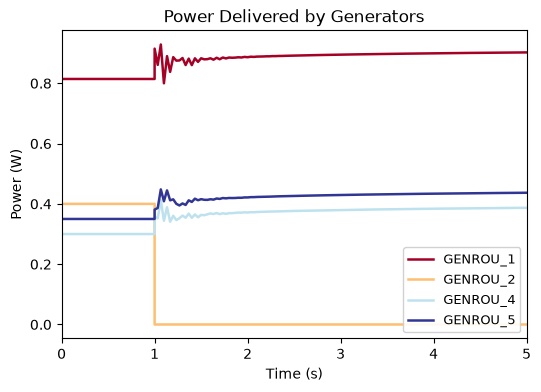

In [ ]:
# Power Delivered by Generators
generator_power_df = ss.TDS.get_timeseries(ss.GENROU.Pe).loc[:,active]
#print(generator_power_df)

cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, gen in enumerate(generator_power_df.columns):
    color = cmap(i / (len(generator_power_df.columns) - 1))

    ax.plot(generator_power_df.index, generator_power_df[gen], color=color, linewidth=1.8,
            label=f"{gen}")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (W)")
ax.set_title("Power Delivered by Generators")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(0.0, 5.0)
# ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)


# Calculations
Calculate